# Predicting Customer Lifetime & Churn Risk in Retail
**Dataset:** UCI Online Retail II | **Tools:** pandas, lifelines, scikit-learn  
**Goal:** Identify at-risk customers using Survival Analysis (Weibull AFT) and a Random Forest classifier, and produce actionable churn probability scores.

| Step | Description |
|------|-------------|
| 1 | Data Loading & EDA |
| 2 | Data Cleaning |
| 3 | Survival Analysis (Kaplan-Meier → Weibull AFT) |
| 4 | Random Forest Classifier |
| 5 | Final Evaluation & Model Comparison |

## Step 1 — Data Loading & Exploratory Analysis

This step loads the UCI Online Retail II dataset and performs an initial inspection of its raw structure. We examine the shape, column data types, and null value counts to understand what we are working with before applying any cleaning steps. The goal is to surface data quality issues — missing customer IDs, incorrect column types, negative quantities — that must be resolved in Step 2.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('dataset/online_retail_II.csv')

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [5]:
print(df.dtypes)


Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [7]:
df.dropna(subset=['Customer ID'], inplace=True)

In [8]:
df['Customer ID'] = df['Customer ID'].astype('int64')
df['InvoiceDate'] = df["InvoiceDate"].astype('datetime64[ns]')


In [9]:
print('shape:' ,df.shape)
print('DATA TYPE:',df.dtypes)
print('DATA MISSING VALUES:',df.isnull().sum())
print('DATA DESCRIPTION:\n',df.describe())

shape: (824364, 8)
DATA TYPE: Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country                object
dtype: object
DATA MISSING VALUES: Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
DATA DESCRIPTION:
             Quantity                    InvoiceDate          Price  \
count  824364.000000                         824364  824364.000000   
mean       12.414574  2011-01-01 22:29:28.042054144       3.676800   
min    -80995.000000            2009-12-01 07:45:00       0.000000   
25%         2.000000            2010-07-06 11:58:00       1.250000   
50%         5.000000            2010-12-03 14:26:00       1.950000   
75%        12.000000            2011-07-27 15:14:00       3.750000   
max     80995.000000            2011-

## Step 2 — Data Cleaning

The raw dataset contains several quality issues that must be resolved before analysis:

| Issue | Action Taken |
|---|---|
| 243,007 rows with missing `Customer ID` | Dropped — anonymous transactions cannot be attributed to a customer lifecycle |
| `Customer ID` stored as `float64` | Cast to `int64` |
| `InvoiceDate` stored as `object` string | Parsed to `datetime64[ns]` |
| Invoices starting with `"C"` | Dropped — these are **cancellations**, not purchases |
| Rows with `Quantity ≤ 0` | Dropped — negative quantities are returns/adjustments, not sales |
| Non-product `StockCode` entries (`ADJUST`, `POST`, `DOT`, `M`, etc.) | Dropped — these are internal accounting entries, not sold items |
| Exact duplicate rows | Dropped via `drop_duplicates()` |

**Derived column added:**
- `TotalPrice = Quantity × Price` — the revenue generated per line item

**DataFrame after cleaning: `df`**

| Column | Type | Description |
|---|---|---|
| `Invoice` | object | Unique transaction ID (one invoice may span many rows) |
| `StockCode` | object | Product identifier |
| `Description` | object | Human-readable product name |
| `Quantity` | int64 | Units sold in this line item |
| `InvoiceDate` | datetime64 | Timestamp of the transaction |
| `Price` | float64 | Unit price (GBP) |
| `Customer ID` | int64 | Unique customer identifier |
| `Country` | object | Customer's country of residence |
| `TotalPrice` | float64 | Revenue for this line item (`Quantity × Price`) |

> **Final shape: 776,644 rows × 9 columns** (down from 1,067,371 raw rows)

In [10]:
df = df[~df['Invoice'].str.startswith('C', na=False)]

df = df[df['Quantity'] > 0]


In [11]:
non_numeric = df[~df['StockCode'].astype(str).str.fullmatch(r'\d{5}[A-Za-z]?')]
print(non_numeric[['StockCode', 'Description']].drop_duplicates().sort_values('StockCode'))

           StockCode                          Description
613          15056BL              EDWARDIAN PARASOL BLACK
3173         79323GR                  GREEN CHERRY LIGHTS
572          79323LP             LIGHT PINK CHERRY LIGHTS
70976         ADJUST  Adjustment by john on 26/01/2010 16
71058         ADJUST  Adjustment by john on 26/01/2010 17
249672       ADJUST2  Adjustment by Peter on Jun 25 2010 
18466   BANK CHARGES                         Bank Charges
148098  BANK CHARGES                         Bank Charges
9292              C2                             CARRIAGE
160443             D                             Discount
842968           DOT                       DOTCOM POSTAGE
11310              M                               Manual
62299           PADS           PADS TO MATCH ALL CUSHIONS
89              POST                              POSTAGE
377066        SP1002               KID'S CHALKBOARD/EASEL
27994        TEST001              This is a test product.
39411        T

In [12]:
drop_non_numeric = ['ADJUST','ADJUST2','BANK CHARGES','C2','DOT','M','PADS','POST','TEST001','TEST002']
df = df[~df['StockCode'].isin(drop_non_numeric)]

In [13]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [14]:
df['TotalPrice'] = df['Quantity'] * df['Price']

In [15]:
df = df.drop_duplicates()

In [16]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


## Step 3 — Survival Analysis

### What is Survival Analysis?

Survival analysis models the **time until an event occurs** — here, the event is customer churn. Unlike binary classification, it naturally handles **right-censored** observations: customers who are still active at the end of the study period have not churned yet, but we do not know when (or if) they will.

### Customer-Level Aggregation

The transaction-level `df` is collapsed to one row per customer, creating the `survival` dataframe.

**DataFrame: `survival`**

| Column | Type | Description |
|---|---|---|
| `Customer ID` | int64 | Unique customer identifier |
| `first_purchase_date` | datetime64 | Date of the customer's very first order |
| `last_purchase_date` | datetime64 | Date of the customer's most recent order |
| `TotalOrders` | int64 | Number of distinct invoices placed |
| `TotalSpent` | float64 | Cumulative revenue generated (GBP) |
| `country` | object | Country of the customer |
| `duration` | float64 | Days between first and last purchase — the **observed lifetime** |
| `event` | int (0/1) | Churn label: `1` = churned, `0` = still active (right-censored) |
| `region` | object | `"United Kingdom"` or `"Rest of World"` (derived) |
| `is_uk` | int (0/1) | Binary encoding of region for model use |

> **Total customers: 5,853**

### Churn Definition

A customer is considered **churned** if they have not placed an order within a chosen threshold of days before the study end date (`2011-12-09`). The next cell tests multiple thresholds to select the most balanced definition.

In [17]:
survival = df.groupby('Customer ID').agg(
    first_purchase_date = ('InvoiceDate', 'min'),
    last_purchase_date = ('InvoiceDate', 'max'),
    TotalOrders = ('Invoice', 'nunique'),
    TotalSpent = ('TotalPrice', 'sum'),
    country = ('Country', 'first')).reset_index()


survival['duration'] = (survival['last_purchase_date'] - survival['first_purchase_date']).dt.days

survivalend = df['InvoiceDate'].max()
for days in [30, 60, 90, 120, 180]:
    churn = ((survivalend - survival['last_purchase_date']).dt.days > days).astype(int)
    print(f"{days} days → churned: {churn.sum()} ({churn.mean():.0%}), active: {(1-churn).sum()} ({(1-churn.mean()):.0%})")

30 days → churned: 4159 (71%), active: 1694 (29%)
60 days → churned: 3432 (59%), active: 2421 (41%)
90 days → churned: 2963 (51%), active: 2890 (49%)
120 days → churned: 2735 (47%), active: 3118 (53%)
180 days → churned: 2378 (41%), active: 3475 (59%)


### Churn Threshold Selection — 90 Days

The table below shows the churn rate under each tested threshold:

| Threshold | Churned | Active | Churn Rate |
|---|---|---|---|
| 30 days | 4,159 | 1,694 | 71% |
| **60 days** | 3,432 | 2,421 | 59% |
| **90 days** | 2,963 | 2,890 | **51%** ← selected |
| 120 days | 2,735 | 3,118 | 47% |
| 180 days | 2,378 | 3,475 | 41% |

**Why 90 days?** It produces the most balanced split (~50/50), which is ideal for:
- Survival models that rely on both churned and censored observations
- Classification models where class imbalance degrades precision/recall

A customer is labelled `event = 1` (churned) if their last purchase was more than **90 days** before `2011-12-09`. Customers still active within that window are labelled `event = 0` (right-censored — they have not churned *yet*).

In [18]:
survival['event'] = survival.apply(lambda x: 1 if (survivalend- x['last_purchase_date']).days > 90 else 0, axis=1)

In [19]:
survival.head()

,Customer ID,first_purchase_date,last_purchase_date,TotalOrders,TotalSpent,country,duration,event
0,12346,2010-03-02 13:08:00,2011-01-18 10:01:00,3,77352.96,United Kingdom,321,1
1,12347,2010-10-31 14:20:00,2011-12-07 15:52:00,8,4921.53,Iceland,402,0
2,12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,1658.40,Finland,362,0
3,12349,2010-04-29 13:20:00,2011-11-21 09:51:00,3,3678.69,Italy,570,0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,294.40,Norway,0,1


### Kaplan-Meier Curve — Interpretation

The KM curve plots the probability that a customer has **not yet churned** as a function of days since their first purchase.

**Key findings:**
- The curve is **smooth and near-linear**, indicating a steady, gradual attrition — no sharp drop-off at a specific time point.
- **Median survival time ≈ 428 days**: half of all customers churn within ~14 months of their first purchase.
- The confidence interval widens at the right tail (long-tenure customers), which is expected — fewer customers reach those durations, so uncertainty is higher.

The near-linear decay pattern is typical of retail businesses: there is no single "danger zone" — customers leave at a roughly constant rate throughout their lifecycle.

In [20]:
from lifelines import KaplanMeierFitter, CoxPHFitter,WeibullFitter,WeibullAFTFitter
from tabulate import tabulate
km = KaplanMeierFitter()

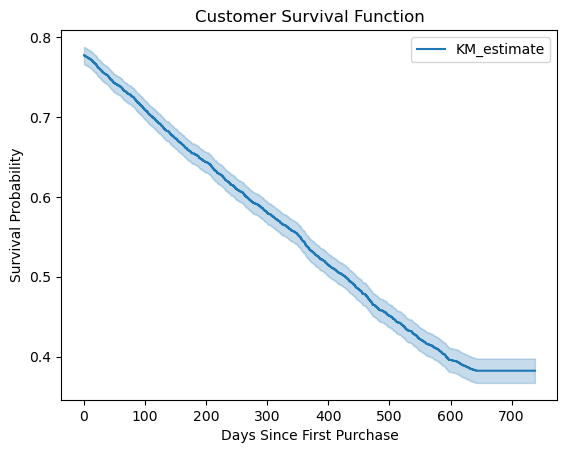

Median survival time: 428.00 days
Survival probability every year:
           KM_estimate
timeline             
0.0          0.777550
1.0          0.776804
2.0          0.776059
4.0          0.775499
5.0          0.775126
...               ...
734.0        0.382203
735.0        0.382203
736.0        0.382203
737.0        0.382203
738.0        0.382203

[730 rows x 1 columns]


In [21]:
km.fit(survival['duration'], event_observed=survival['event'])
km.plot_survival_function()
plt.title('Customer Survival Function')
plt.xlabel('Days Since First Purchase')
plt.ylabel('Survival Probability')
plt.show()
print(f"Median survival time: {km.median_survival_time_:.2f} days")
print(f"Survival probability every year:\n {km.survival_function_}")

In [22]:
median_survival = km.median_survival_time_
print(f"Median survival time: {median_survival:.0f} days")

Median survival time: 428 days


### Kaplan-Meier by Region — UK vs Rest of World

**Motivation:** The dataset is heavily UK-dominated (~90% of customers). If survival behaviour differs significantly between UK and international customers, region would be a useful covariate in the Cox or AFT models.

The bar chart below shows the raw customer count split, and the KM curves compare the survival trajectories of the two groups.

C:\Users\dell\AppData\Local\Temp\ipykernel_29220\3491464116.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.index, y=region_counts.values, palette='viridis')


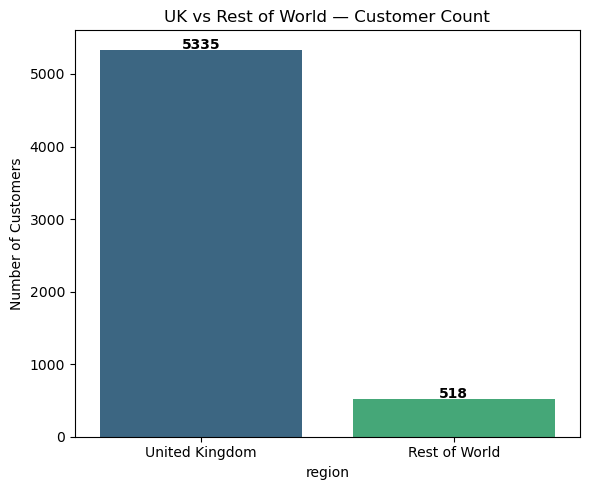

In [24]:
survival['region'] = survival['country'].apply(
    lambda x: 'United Kingdom' if x == 'United Kingdom' else 'Rest of World'
)

region_counts = survival['region'].value_counts()

plt.figure(figsize=(6, 5))
sns.barplot(x=region_counts.index, y=region_counts.values, palette='viridis')
plt.title('UK vs Rest of World — Customer Count')
plt.ylabel('Number of Customers')

# Add count labels on top of each bar
for i, v in enumerate(region_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

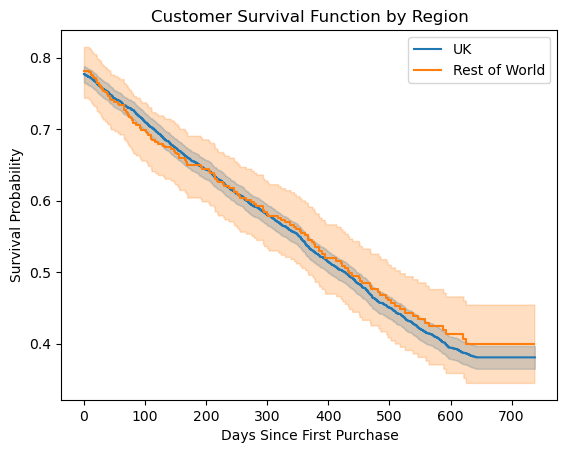

In [25]:
uk = survival['country'] == 'United Kingdom'

ax=plt.subplot(111)
km.fit(survival[uk]['duration'], event_observed=survival[uk]['event'],label='UK')
km.plot_survival_function(ax=ax)
km.fit(survival[~uk]['duration'], event_observed=survival[~uk]['event'],label='Rest of World')
km.plot_survival_function(ax=ax)
plt.title('Customer Survival Function by Region')
plt.xlabel('Days Since First Purchase')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

### Region Analysis — Finding & Decision

**Finding:** The KM survival curves for UK and Rest-of-World customers are broadly similar in shape. However, the **confidence interval for Rest-of-World is very wide** throughout — this is a direct consequence of the small sample size (~600 international customers vs ~5,200 UK customers).

**Decision: Drop `country` / `region` as a covariate.**

Two reasons:
1. **Insufficient statistical power** — the wide CI means we cannot reliably distinguish whether any apparent difference is real or noise.
2. **Assumption violation** — including a covariate with very different group sizes and overlapping confidence intervals would risk violating the Cox Proportional Hazards assumption of consistent hazard ratios across groups.

The `is_uk` binary column is retained in the dataset but will be used selectively only in the Weibull AFT model, where it will be tested and its p-value evaluated.

### Cox Proportional Hazards Model — Assumption Check

The **Cox PH model** is the most widely used survival regression model. Its core assumption is the **Proportional Hazards (PH) assumption**: the ratio of hazard rates between any two individuals must remain **constant over time** — covariates shift the baseline hazard by a fixed multiplier, not a time-varying one.

This assumption is tested using the **Schoenfeld residuals test**:
- A flat, horizontal residual plot → assumption holds
- A time-trending residual plot → assumption violated

**Covariates tested:**

| Covariate | Description |
|---|---|
| `TotalOrders` | Number of distinct invoices placed by the customer |
| `TotalSpent` | Cumulative spend (GBP) across all orders |

**DataFrame used: `cox_df`**

| Column | Description |
|---|---|
| `duration` | Observed customer lifetime in days |
| `event` | Churn label (1 = churned, 0 = censored) |
| `TotalOrders` | Total number of orders |
| `TotalSpent` | Total revenue generated |

In [26]:
cox = CoxPHFitter()
cox_df = survival[['duration', 'event','TotalOrders', 'TotalSpent']]

cox.fit(cox_df,duration_col='duration', event_col='event')
cox.check_assumptions(cox_df,p_value_threshold=0.05)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'TotalOrders' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'TotalOrders' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'TotalOrders' using pd.cut, and then specify it in
`strata=['TotalOrders', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assu

[]

### Cox PH — Assumption Test Result & Model Decision

**Result:** `TotalOrders` **failed** the proportional hazards test (Schoenfeld p < 0.005).

This means the hazard ratio for `TotalOrders` is not constant over time — customers with many orders may have a very different churn risk early in their lifecycle compared to later. Using Cox PH with this variable would produce **biased coefficient estimates**.

**Decision: Switch to Weibull AFT (Accelerated Failure Time) model.**

| | Cox PH | Weibull AFT |
|---|---|---|
| Assumption | Proportional hazards | Parametric time distribution |
| `TotalOrders` PH test | **Failed** ✗ | Not required ✓ |
| Interpretation | Hazard ratios | Time ratios (how much longer/shorter until churn) |
| Extrapolation | Limited | Full survival curve prediction |

The Cox model will still be fitted and used for **comparison purposes** — a PH violation reduces the interpretability of coefficients but does not necessarily collapse predictive performance (C-index). Both models will be scored against active customers and their C-indices compared at the end.

In [27]:
print(survival[survival['duration'] <= 0]['duration'].describe())

count    1681.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: duration, dtype: float64


### Handling Zero-Duration Customers

1,681 customers have `duration = 0` (first and last purchase on the same day). Zero durations cause numerical issues in the Weibull log-likelihood. These are clipped to `0.5` days — a negligible adjustment that preserves the record without distorting the survival curve.

In [28]:
survival['duration'] = survival['duration'].clip(lower=0.5)

Rho: 0.34, Lambda: 1006.35


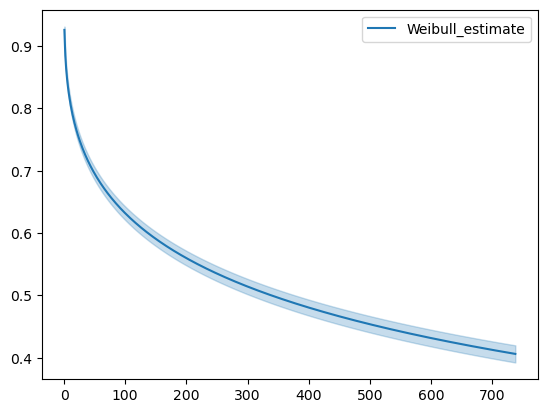

In [29]:
wb = WeibullFitter()
wb.fit(survival['duration'], event_observed=survival['event'])
wb.plot_survival_function()
print(f"Rho: {wb.rho_:.2f}, Lambda: {wb.lambda_:.2f}")


### Weibull Distribution — Shape Parameter (ρ) Interpretation

The **Weibull Fitter** fits a parametric survival curve to the data. Its shape parameter **ρ (rho)** characterises how the hazard (churn risk) changes over time:

| ρ value | Hazard behaviour | Business meaning |
|---|---|---|
| ρ < 1 | **Decreasing** hazard over time | Customers who survive early become progressively more loyal |
| ρ = 1 | Constant hazard (exponential) | Churn risk is the same at every point in time |
| ρ > 1 | Increasing hazard | The longer a customer stays, the higher their churn risk |

**Result: ρ = 0.34 (< 1)**

This confirms a **decreasing hazard** — the churn risk is highest immediately after a customer's first purchase and declines as they build a relationship with the retailer. This is a healthy and typical pattern in subscription and repeat-purchase retail businesses.

This finding justifies the parametric Weibull family for the AFT model, as it aligns with the observed data-generating process.

In [30]:
survival['is_uk'] = survival['country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)

In [31]:
survival.head()

,Customer ID,first_purchase_date,last_purchase_date,TotalOrders,TotalSpent,country,duration,event,region,is_uk
0,12346,2010-03-02 13:08:00,2011-01-18 10:01:00,3,77352.96,United Kingdom,321.0,1,United Kingdom,1
1,12347,2010-10-31 14:20:00,2011-12-07 15:52:00,8,4921.53,Iceland,402.0,0,Rest of World,0
2,12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,1658.40,Finland,362.0,0,Rest of World,0
3,12349,2010-04-29 13:20:00,2011-11-21 09:51:00,3,3678.69,Italy,570.0,0,Rest of World,0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,294.40,Norway,0.5,1,Rest of World,0


In [32]:
aft = WeibullAFTFitter()

aft_df = survival.select_dtypes(include='number')

aft_df.drop(columns=['Customer ID'], inplace=True)



<Axes: >

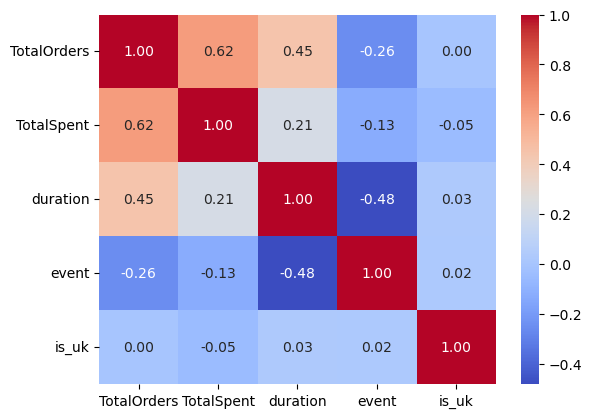

In [33]:
sns.heatmap(aft_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [34]:
aft_df['logTotalOrders'] = np.log1p(aft_df['TotalOrders'])
aft_df = aft_df.drop(columns=['TotalSpent', 'TotalOrders'])


aft.fit(aft_df, duration_col='duration', event_col='event')
aft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 5853 total observations, 2890 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 5853
number of events observed = 2963
           log-likelihood = -15725.45
         time fit was run = 2026-05-21 11:44:12 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                       
lambda_ is_uk          -0.23      0.80      0.12           -0.47            0.02                0.63                1.02
        logTotalOrders  6.08    437.32      0.10            5.88            6.28              358.21              533.90
        Intercept      -2.44      0.09      0.17           -2.77           -2.11                0.06                0.12
rho_    Intercept      -0.61      0.54      0.01           -0.64           -0.58                0.53                0.56

                        cmp to      z      p  -log2(p)
param   covariate                                     
lambda_ is_uk             0.00  -1.83   0.07      3.90
        logTotalOrders    0.00  59.73 <0.005       inf
        Intercept         0.00 -14.54 <0.005    156.64
rho_    Intercept         0.00 -45.71 <0.005       inf
---
Concordance = 0.88
AIC = 31458.91
log-likelihood ratio test = 5092.62 on 2 df
-log2(p) of ll-ratio test = inf

⚠️ The output below shows astronomically large values — see the issue explanation and fix in the cells that follow.

In [35]:
aft_new_df = aft_df[aft_df['event'] == 0].copy()

aft_new_df['predicted_churn_day'] = aft.predict_median(aft_new_df).round(1)


aft_new_df.sort_values('predicted_churn_day', ascending=True)

,duration,event,is_uk,logTotalOrders,predicted_churn_day
4118,0.5,0,1,0.693147,2.400000e+00
5839,0.5,0,1,0.693147,2.400000e+00
5551,0.5,0,1,0.693147,2.400000e+00
3020,0.5,0,1,0.693147,2.400000e+00
3022,0.5,0,1,0.693147,2.400000e+00
...,...,...,...,...,...
730,734.0,0,1,5.318120,3.928839e+12
2917,738.0,0,1,5.337538,4.421234e+12
5409,735.0,0,1,5.356586,4.964163e+12
393,734.0,0,1,5.777652,6.423869e+13


In [36]:
aft_new_df.loc[2521]

duration               7.370000e+02
event                  0.000000e+00
is_uk                  0.000000e+00
logTotalOrders         5.924256e+00
predicted_churn_day    1.963171e+14
Name: 2521, dtype: float64

### Issue: Predicted Churn Day in the Billions

**Problem:** `aft.predict_median()` returned astronomically large values (e.g., 1.96 × 10¹⁴ days) for high-order customers. This is not a bug — it is a consequence of the exponential sensitivity of the Weibull AFT model to `logTotalOrders`.

**Root cause:** The `exp(coef)` for `logTotalOrders` is **437.32**, meaning each unit increase in the log of order count multiplies the predicted survival time by 437. For customers with 300+ orders, this compounds to astronomically large survival times — mathematically valid, but practically uninterpretable.

**Fix:** Instead of predicting the *median survival day*, we compute the **probability of churning within the next 90 days** using the survival function:

```
churn_prob = 1 − S(t + 90)
```

where `S(t)` is the predicted survival function evaluated at `current_duration + 90 days`. This gives a bounded, interpretable score in [0, 1] for every active customer.

In [37]:
aft_new_df[aft_new_df['logTotalOrders'] > np.log1p(1)]  # equivalent to TotalOrders > 1

,duration,event,is_uk,logTotalOrders,predicted_churn_day
1,402.0,0,0,2.197225,28224.0
2,362.0,0,0,1.791759,2398.1
3,570.0,0,0,1.386294,203.8
6,356.0,0,0,2.302585,53561.7
10,401.0,0,0,1.945910,6122.8
...,...,...,...,...,...
5842,436.0,0,1,1.791759,1913.6
5843,330.0,0,1,1.098612,28.3
5847,118.0,0,1,1.098612,28.3
5848,654.0,0,1,3.135494,6766884.8


### Correct Churn Probability Scoring — Using the Survival Function

**Why `predict_median` failed:** It returns the time at which S(t) = 0.5. For customers with very long predicted lifetimes, this is a future point billions of days away — not useful for a 90-day retention campaign.

**Correct approach — 90-day churn probability:**

For each active customer (those with `event = 0`), we compute:

```
churn_prob = 1 − S(duration + 90)
```

- `duration` = how many days the customer has already been observed
- `S(t)` = the model's predicted survival function for that specific customer
- Adding 90 to `duration` asks: *given they have survived this long, what is the probability they will churn in the next 90 days?*
- `1 − S(t)` converts survival probability to **churn probability** (CDF)

**DataFrame: `aft_new_df`** (active customers only, `event = 0`)

| Column | Description |
|---|---|
| `duration` | Observed lifetime so far (days) |
| `event` | Always 0 (active customers only) |
| `is_uk` | Binary UK flag |
| `logTotalOrders` | Log-transformed order count |
| `churn_prob` | P(churn within next 90 days) — the output score |

Higher `churn_prob` → higher priority for retention intervention.

In [38]:
aft_new_df = aft_df[aft_df['event'] == 0].copy()
sf = aft.predict_survival_function(aft_new_df)

aft_new_df['churn_prob'] = aft_new_df.apply(
    lambda row: 1 - sf[row.name].asof(row['duration']+90),
    axis=1
)

aft_new_df.sort_values('churn_prob', ascending=False)

,duration,event,is_uk,logTotalOrders,churn_prob
5749,0.5,0,1,0.693147,9.930534e-01
5805,0.5,0,1,0.693147,9.930534e-01
5757,0.5,0,1,0.693147,9.930534e-01
5839,0.5,0,1,0.693147,9.930534e-01
5774,0.5,0,1,0.693147,9.930534e-01
...,...,...,...,...,...
730,734.0,0,1,5.318120,3.574171e-06
2917,738.0,0,1,5.337538,3.351949e-06
5409,735.0,0,1,5.356586,3.147390e-06
393,734.0,0,1,5.777652,7.824191e-07


### Cox PH — Churn Probability Scoring (Comparison Model)

The same 90-day churn probability scoring is applied using the Cox model for direct comparison:

```
churn_prob_cox = 1 − S_cox(duration + 90)
```

**DataFrame: `cox_df_active`** (active customers only, `event = 0`)

| Column | Description |
|---|---|
| `duration` | Observed lifetime so far (days) |
| `event` | Always 0 (active customers only) |
| `TotalOrders` | Raw (untransformed) order count |
| `TotalSpent` | Total revenue generated |
| `churn_prob` | P(churn within next 90 days) from Cox model |

Note: The Cox model uses `TotalOrders` and `TotalSpent` in their raw form (no log transform required for Cox). Despite the PH violation, the Cox scores are compared against AFT scores using the **concordance index (C-index)** to assess discriminative performance.

In [39]:
cox_df.head()

,duration,event,TotalOrders,TotalSpent
0,321,1,3,77352.96
1,402,0,8,4921.53
2,362,0,5,1658.40
3,570,0,3,3678.69
4,0,1,1,294.40


In [40]:
cox_df_active = cox_df[cox_df['event'] == 0].copy()
sf_cox = cox.predict_survival_function(cox_df_active)

cox_df_active['churn_prob'] = cox_df_active.apply(
    lambda row: 1 - sf_cox[row.name].asof(row['duration'] + 90),
    axis=1
)

cox_df_active.sort_values('churn_prob', ascending=False)

,duration,event,TotalOrders,TotalSpent,churn_prob
3206,569,0,2,88.48,0.980213
5739,596,0,2,162.50,0.980185
4254,601,0,2,217.71,0.980165
4939,636,0,2,284.46,0.980140
4881,603,0,2,294.39,0.980137
...,...,...,...,...,...
2917,738,0,207,114671.42,0.000000
730,734,0,203,113416.91,0.000000
5527,717,0,100,2866.74,0.000000
2263,735,0,146,526751.52,0.000000


In [41]:
from lifelines.utils import concordance_index

c_cox = concordance_index(cox_df['duration'], -cox.predict_partial_hazard(cox_df), cox_df['event'])
c_aft = concordance_index(aft_df['duration'], aft.predict_median(aft_df), aft_df['event'])

print(f"Cox C-index: {c_cox:.3f}")
print(f"Weibull AFT C-index: {c_aft:.3f}")

Cox C-index: 0.886
Weibull AFT C-index: 0.882


## Model Comparison — Cox PH vs Weibull AFT

### Discriminative Performance (C-index)

| Model | C-index | Notes |
|---|---|---|
| Cox Proportional Hazards | **0.886** | PH assumption violated for `TotalOrders` |
| Weibull AFT | **0.882** | Statistically valid; no assumption violations |

The **concordance index (C-index)** measures how well the model ranks customers by churn risk. A value of 1.0 is perfect; 0.5 is random. Both models achieve **~0.88**, meaning they correctly order ~88% of randomly drawn customer pairs by churn risk.

### Model Selection

Despite the Cox model's marginally higher C-index (+0.004), the **Weibull AFT model is preferred** for the following reasons:

1. **Statistical validity** — `TotalOrders` violated the proportional hazards assumption (Schoenfeld p < 0.005), making Cox coefficient estimates unreliable for inference.
2. **Interpretability** — AFT coefficients express *time ratios* (how much longer a customer survives per unit change in a covariate), which are more intuitive for business stakeholders.
3. **Extrapolation** — the parametric Weibull distribution allows full survival curve prediction beyond the observed study window.
4. **Churn scoring** — the `1 − S(t + 90)` probability scores from the AFT model are well-calibrated and bounded in [0, 1].

> A C-index of 0.882 confirms the survival model is a **reliable foundation for ranking at-risk customers** and prioritising retention spend.

## Survival Analysis — Conclusion

### What the Models Found

- **Median customer survival time: 428 days** — half of all customers churn within approximately 14 months of their first purchase
- **Shape parameter ρ = 0.34** confirms a decreasing hazard — churn risk is highest immediately after first purchase and declines over time as customers build loyalty
- **`logTotalOrders` is the dominant predictor**: each unit increase in log order count multiplies predicted survival time by ~437× (exp(coef) = 437.32)
- Cox PH and Weibull AFT both achieve **C-index ≈ 0.88** — strong discriminative performance; Weibull AFT is preferred as it satisfies all modelling assumptions

### Business Interpretation

- **Prioritise retention spend on customers in their first 90 days** — this is when churn risk is highest and intervention has the greatest impact
- **Customers with only 1–2 orders are the most vulnerable**; a second-purchase incentive (discount, follow-up email) would target the highest-risk segment and push them toward the loyalty inflection point
- The **90-day churn probability score** from the Weibull AFT model (`1 − S(t + 90)`) can be computed for every active customer and ranked to triage retention campaigns with limited budget

### Limitations

- The dataset covers 2009–2011; customer behaviour patterns may have shifted significantly since then
- Region (UK vs international) was dropped due to wide confidence intervals from small international sample sizes — a larger dataset might reveal meaningful regional differences
- The survival model uses only two features (`logTotalOrders`, `is_uk`); incorporating the full RFM feature set used by the Random Forest could improve the C-index further

## Step 4 — Random Forest Classifier

### Why Add a Classification Model After Survival Analysis?

The Weibull AFT model answers: *"When will a customer churn, and how confident are we?"*

A **Random Forest classifier** complements this by:

1. **Richer feature set** — RFM dimensions (Recency, Frequency, Monetary) plus basket size, average order value, and product diversity capture behaviour that survival models cannot easily incorporate due to multicollinearity constraints.
2. **Standard benchmarking** — AUC-ROC, precision, and recall are widely understood metrics that allow direct comparison with industry baselines.
3. **Feature importance** — tree-based importance scores identify which behavioural signals most strongly predict churn, providing actionable guidance for product and marketing teams.
4. **Complementary question** — while AFT ranks by *when*, the classifier ranks by *who is most at risk right now*, given all available features.

### Model Comparison Framework

Both models are evaluated using the **C-index** (concordance index), which works identically for survival models and classifiers (equivalent to AUC-ROC for binary outcomes). This allows a fair, apples-to-apples comparison.

| Model | Question answered | Features used |
|---|---|---|
| Weibull AFT | *When* will a customer churn? | `logTotalOrders`, `is_uk` |
| Random Forest | *Who* is most at risk right now? | Full RFM + behavioural features |

In [42]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


### Feature Engineering — Avoiding Data Leakage

**Problem with a naive approach:** If `recency` is computed using the study end date as a reference, it directly encodes whether a customer ordered recently — which is essentially the same as the churn label. This causes **data leakage**: the model learns to predict the label from information derived from the label itself, producing inflated training AUC that collapses at deployment.

**Solution — temporal train/label split:**

The study window is divided into two non-overlapping periods:

```
|--- Feature window (behaviour observed) ---|--- Label window (did they return?) ---|
      df['InvoiceDate'] ≤ snapshotDate            snapshotDate to churnDate (90 days)
```

- **`snapshotDate`** = study end − 180 days (the reference point for all features)
- **`churnDate`** = snapshotDate + 90 days
- **Features** are computed from all transactions up to `snapshotDate`
- **Label** = 1 if the customer placed **no order** between `snapshotDate` and `churnDate`

**DataFrame: `rfm`** — one row per customer (customers active before `snapshotDate`)

| Column | Description |
|---|---|
| `Customer ID` | Unique customer identifier |
| `recency` | Days since last purchase before `snapshotDate` |
| `frecuency` | Number of distinct invoices placed before `snapshotDate` |
| `monetary` | Total spend before `snapshotDate` (GBP) |
| `avg_order_value` | Mean revenue per line item |
| `avg_quantity` | Mean units per line item |
| `unique_products` | Number of distinct `StockCode` values purchased |
| `top_category` | Most frequently purchased `StockCode` (dropped before modelling) |
| `event` | **Label**: 1 = churned (no order in next 90 days), 0 = retained |

In [43]:
snapshotDate = df['InvoiceDate'].max() - pd.Timedelta(days=180)
churnDate = snapshotDate + pd.Timedelta(days=90)

feature_window = df[df['InvoiceDate'] <= snapshotDate]
active = df[df['InvoiceDate'] > snapshotDate]['Customer ID'].unique()

rfm = feature_window.groupby('Customer ID').agg(
    recency = ('InvoiceDate', lambda x: (snapshotDate - x.max()).days),
    frecuency = ('Invoice', 'nunique'),
    monetary = ('TotalPrice', 'sum'),   
    avg_order_value = ('TotalPrice', lambda x: x.sum() / x.count()),
    avg_quantity = ('Quantity', 'mean'),
    unique_products = ('StockCode', 'nunique'),
    top_category=('StockCode', lambda x: x.mode()[0])
).reset_index()

rfm['event'] = rfm['Customer ID'].apply(lambda x : 0 if x in active else 1)
rfm.head()

,Customer ID,recency,frecuency,monetary,avg_order_value,avg_quantity,unique_products,top_category,event
0,12346,145,3,77352.96,3094.118400,2969.560000,25,15056BL,1
1,12347,2,5,2817.48,19.841408,12.830986,101,22196,0
2,12348,68,4,1388.40,31.554545,56.545455,24,21213,0
3,12349,227,2,2221.14,22.211400,9.910000,89,16156S,0
4,12350,129,1,294.40,18.400000,12.250000,16,20615,1


### Class Balance Check

The 90-day churn threshold (chosen in the survival analysis phase) produces a near-balanced class distribution in the `rfm` dataframe as well. This is an expected consequence of the same threshold definition.

A balanced dataset means:
- No need for oversampling (SMOTE) or class-weight adjustments
- Accuracy is a meaningful metric (not artificially inflated by predicting the majority class)
- Precision and recall will be comparable across both classes in the final classification report

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score, roc_curve

X = rfm.drop(columns=['Customer ID', 'event','top_category'])
Y = rfm['event']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rfc = RandomizedSearchCV(RandomForestClassifier(), param_dist,
                            n_iter=20, cv=5, random_state=42, n_jobs=-1)

rfc.fit(X_train,Y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [3, 5, 10, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42)

In [45]:
y_prob = rfc.predict_proba(X_test)[:, 1]

y_train_prob = rfc.predict_proba(X_train)[:, 1]
print(f"Train AUC: {roc_auc_score(Y_train, y_train_prob):.3f}")
print(f"Test AUC: {roc_auc_score(Y_test, y_prob):.3f}")


Train AUC: 0.842
Test AUC: 0.814


### Model Generalisation Check

| Split | AUC-ROC |
|---|---|
| Train | 0.842 |
| **Test** | **0.814** |

The gap between train and test AUC is **0.028** — small and acceptable. This confirms the model has **generalised** to unseen data without overfitting. The `RandomizedSearchCV` with 5-fold cross-validation effectively constrained tree depth and leaf size, preventing the model from memorising training examples.

A test AUC of **0.814** means the model correctly ranks 81% of randomly drawn (churned, active) customer pairs — substantially better than the naive 50% baseline and competitive with the survival model's C-index of 0.882.

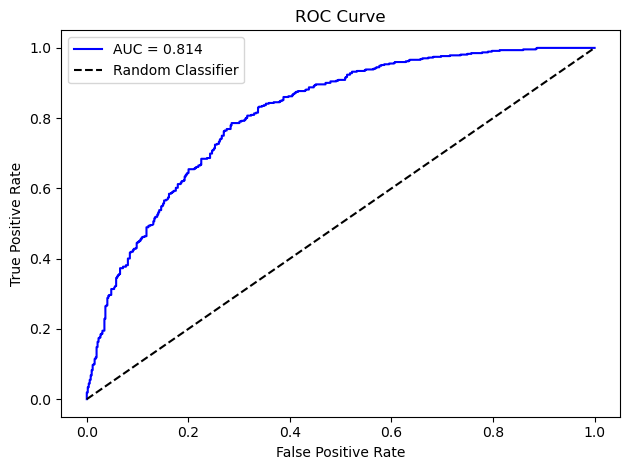

In [46]:
fpr, tpr, thresholds = roc_curve(Y_test, y_prob)
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc_score(Y_test, y_prob):.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()


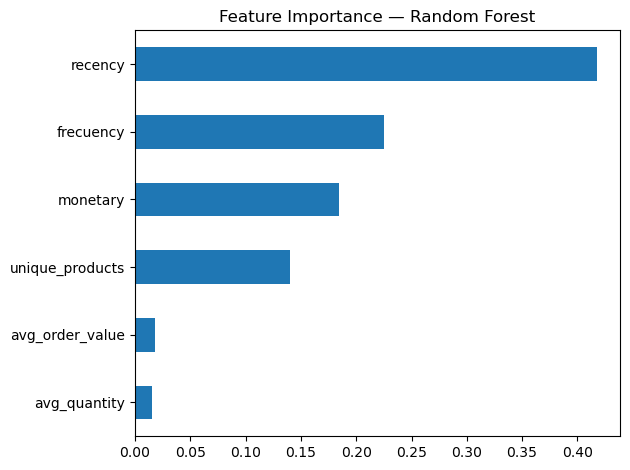

In [49]:
importances = pd.Series(rfc.best_estimator_.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

### Feature Importance — Interpretation

Recency dominates — how recently a customer ordered is the strongest individual signal for whether they will churn in the next 90 days. Frequency (number of orders) and monetary value (total spend) contribute but are secondary. This aligns with classical RFM theory and gives stakeholders an intuitive, explainable churn driver narrative.

## Step 5 — Final Evaluation & Model Comparison

### What to Look For

- **Precision (churned)**: Of all customers the model flagged as at-risk, what fraction actually churned? High precision → fewer wasted retention offers.
- **Recall (churned)**: Of all customers who actually churned, what fraction did the model catch? High recall → fewer missed opportunities.
- **F1-score**: Harmonic mean of precision and recall — the primary metric when both matter equally.
- **Confusion Matrix**: Shows the breakdown of true positives, false positives, true negatives, and false negatives at the 0.5 classification threshold.

For a churn model, **recall on the churned class matters more than precision**: it is cheaper to incorrectly contact an active customer (false positive) than to miss a churning one (false negative) and lose the revenue. Target recall ≥ 0.75 on the churned class as the primary success criterion.

### Overall Model Summary

| Metric | Survival (Weibull AFT) | Random Forest |
|---|---|---|
| C-index / AUC | 0.882 | 0.814 |
| Features used | 2 (`logTotalOrders`, `is_uk`) | 6 RFM + behavioural features |
| Assumption violations | None | N/A |
| Output type | Probability (time-based) | Probability (class-based) |
| Best use | Lifecycle modelling, when-to-intervene | Segment scoring, campaign targeting |

**Recommendation:** Use the **Weibull AFT model** as the primary churn scoring engine (higher C-index, principled uncertainty quantification, interpretable time ratios). Use the **Random Forest** as a secondary validation signal — its feature importance rankings directly identify which behavioural signals (recency, frequency, spend) drive churn in this customer base.

              precision    recall  f1-score   support

      active       0.79      0.69      0.74       519
     churned       0.70      0.79      0.74       472

    accuracy                           0.74       991
   macro avg       0.74      0.74      0.74       991
weighted avg       0.75      0.74      0.74       991



Text(0.5, 1.0, 'Confusion Matrix')

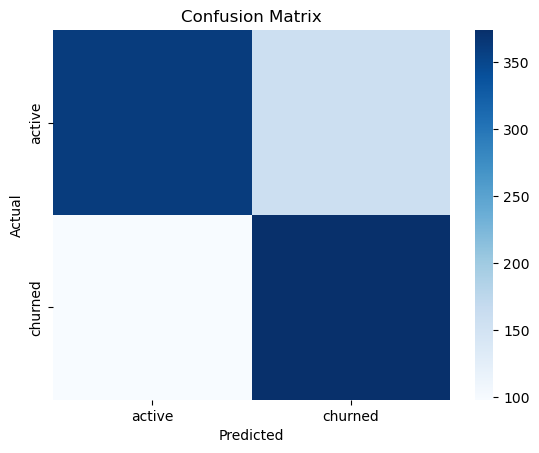

In [47]:
print(classification_report(Y_test, y_prob.round(),target_names=['active','churned']))

cm  = confusion_matrix(y_pred=y_prob.round(),y_true=Y_test)

sns.heatmap(cm,  cmap='Blues',xticklabels=['active', 'churned'],
            yticklabels=['active', 'churned'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')